In [4]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import scanpy as sc
import squidpy as sq
import cv2
import matplotlib.pyplot as plt
import lazyslide as zs
from ipywidgets import interact, FloatSlider
import numpy as np
import glob

from pathlib import Path

# import sys
# sys.path.append('/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/workflow/scripts')
# import coda
# import readwrite
# cfg = readwrite.config()

import sys
sys.path.append("/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1")
from norkin_organoid.code.get_embeddings import (
    NorkinOrganoidDataset,
)

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
FEATURES_PATH = "/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoids_h&e/features"

In [6]:
import spatialdata as sd
sdata = sd.read_zarr("/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoids_h&e/features_sdata/proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_output-XETG00059__0003381__1CNN__20250505__170803_comp0_features.zarr")

In [11]:
from norkin_organoid.code.extract_organoid import get_microscopy

tile_coords_hne = sdata.shapes['tile_coords_hne']
microscopy = get_microscopy("1CNN")

In [7]:
sdata

SpatialData object, with associated Zarr store: /work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoids_h&e/features_sdata/proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_output-XETG00059__0003381__1CNN__20250505__170803_comp0_features.zarr
├── Shapes
│     ├── 'cells_in_tile': GeoDataFrame shape: (876, 10) (2D shapes)
│     ├── 'tile_coords_hne': GeoDataFrame shape: (9, 3) (2D shapes)
│     └── 'tile_coords_xenium': GeoDataFrame shape: (9, 3) (2D shapes)
└── Tables
      └── 'features_adata': AnnData (9, 512)
with coordinate systems:
    ▸ 'global', with elements:
        cells_in_tile (Shapes), tile_coords_hne (Shapes), tile_coords_xenium (Shapes)

In [16]:
poly = sdata.shapes['tile_coords_hne'].iloc[0]['geometry']

TypeError: Invalid shape (3, 1484, 1484) for image data

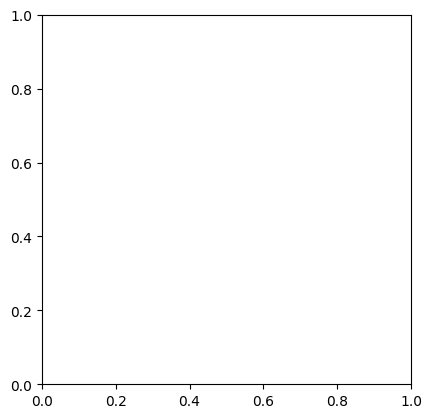

In [ ]:
def extract_polygon_bounding_box_from_microscopy(polygon, microscopy):
    min_x, min_y, max_x, max_y = polygon.bounds
    min_x = int(min_x)
    min_y = int(min_y)
    max_x = int(max_x)
    max_y = int(max_y)
    cropped_image = microscopy[:, min_y:max_y, min_x:max_x]
    return cropped_image

crop = extract_polygon_bounding_box_from_microscopy(poly, microscopy)
crop.shape

plt.imshow(np.moveaxis(crop, 0, -1))

In [ ]:
# Load in the data
import glob
import os
import scanpy as sc
import anndata as ad

anndatas = glob.glob(os.path.join(FEATURES_PATH, "*.h5ad"))  # Adjust path if needed, e.g., "path/to/*.h5ad"
adatas_list = []

for file_path in anndatas:
    organoid_id = os.path.basename(file_path).replace('.h5ad', '')
    adata = sc.read_h5ad(file_path)
    adata.obs['organoid_id'] = organoid_id
    adatas_list.append(adata)

# Merge all AnnData objects
merged_adata = ad.concat(adatas_list, join='outer', index_unique=None)

print(f"Merged AnnData shape: {merged_adata.shape}")
print(f"Organoid IDs: {merged_adata.obs['organoid_id'].unique()}")

Merged AnnData shape: (2286, 512)
Organoid IDs: ['proseg_expected_CRC_PDO_hImmune_v1_dapi_131N_output-XETG00059__0003381__131N__20250505__170803_comp78_features'
 'proseg_expected_CRC_PDO_hImmune_v1_dapi_1J25_output-XETG00059__0003381__1J25__20250505__170803_comp68_features'
 'proseg_expected_CRC_PDO_hImmune_v1_dapi_1GVB_output-XETG00059__0003881__1GVB__20250505__170804_comp40_features'
 'proseg_expected_CRC_PDO_hImmune_v1_dapi_14PT_output-XETG00059__0003381__14PT__20250505__170803_comp13_features'
 'proseg_expected_CRC_PDO_hImmune_v1_dapi_131N_output-XETG00059__0003381__131N__20250505__170803_comp2_features'
 'proseg_expected_CRC_PDO_hImmune_v1_dapi_131N_output-XETG00059__0003381__131N__20250505__170803_comp75_features'
 'proseg_expected_CRC_PDO_hImmune_v1_dapi_1GVB_output-XETG00059__0003881__1GVB__20250505__170804_comp43_features'
 'proseg_expected_CRC_PDO_hImmune_v1_dapi_131N_output-XETG00059__0003381__131N__20250505__170803_comp5_features'
 'proseg_expected_CRC_PDO_hImmune_v1_dapi_

/work/PRTNR/CHUV/DIR/rgottar1/spatial/conda_envs/lazyslide_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## Add in information for cells per tile

In [ ]:

print(adatas_list[1].obs['organoid_id'][0])
adatas_list[1].uns['slide_properties']
histo_x_bounds = (adatas_list[1].uns['slide_properties']['minx'], adatas_list[1].uns['slide_properties']['minx'] + adatas_list[1].uns['slide_properties']['shape'][1])
histo_y_bounds = (adatas_list[1].uns['slide_properties']['miny'], adatas_list[1].uns['slide_properties']['miny'] + adatas_list[1].uns['slide_properties']['shape'][0])
print(histo_x_bounds, "histo_x_bounds")
print(histo_y_bounds, "histo_y_bounds")

adata = adatas_list[1]
# adata.obsm['spatial']

proseg_expected_CRC_PDO_hImmune_v1_dapi_1J25_output-XETG00059__0003381__1J25__20250505__170803_comp68_features
(31838, np.int64(34715)) histo_x_bounds
(9798, np.int64(13271)) histo_y_bounds


/tmp/ipykernel_1821605/3285473197.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(adatas_list[1].obs['organoid_id'][0])


array([[1360., 2584.],
       [ 782., 1805.],
       [1101., 1073.],
       [1101., 1565.],
       [1593., 1073.]])

In [55]:
print(histo_x_bounds,
       histo_y_bounds)

(31838, np.int64(34715)) (9798, np.int64(13271))


In [34]:
adata.uns['slide_properties']

{'bounds': array([   0,    0, 3240, 2701]),
 'level_downsample': array([1.]),
 'level_shape': array([[2701, 3240]]),
 'magnification': None,
 'mpp': 0.08625,
 'n_level': 1,
 'raw': '{"openslide.comment": "<?xml version=\\"1.0\\" encoding=\\"UTF-8\\"?><OME xmlns=\\"http://www.openmicroscopy.org/Schemas/OME/2016-06\\" xmlns:xsi=\\"http://www.w3.org/2001/XMLSchema-instance\\" xsi:schemaLocation=\\"http://www.openmicroscopy.org/Schemas/OME/2016-06 http://www.openmicroscopy.org/Schemas/OME/2016-06/ome.xsd\\" UUID=\\"urn:uuid:4bc2a24c-a9cb-11f0-b5b2-0c42a15da27c\\" Creator=\\"tifffile.py 2025.5.10\\"><Image ID=\\"Image:0\\" Name=\\"Image0\\"><Pixels ID=\\"Pixels:0\\" DimensionOrder=\\"XYCZT\\" Type=\\"uint8\\" SizeX=\\"3240\\" SizeY=\\"2701\\" SizeC=\\"3\\" SizeZ=\\"1\\" SizeT=\\"1\\" Interleaved=\\"true\\"><Channel ID=\\"Channel:0:0\\" SamplesPerPixel=\\"3\\"><LightPath/></Channel><TiffData IFD=\\"0\\" PlaneCount=\\"1\\"/></Pixels></Image></OME>", "openslide.level-count": "1", "openslide.le

In [35]:
def create_subsampled_adata(merged_adata, num_samples=5000, stratified=True):
    def extract_patient_id(organoid_id):
        parts = organoid_id.split('__')
        if len(parts) >= 3:
            return parts[2]
        else:
            return "unknown"
    
    def stratified_subsample(adata, n_total):
        patient_counts = adata.obs['patient_id'].value_counts()
        sample_indices = []
        
        for patient_id, count in patient_counts.items():
            patient_mask = adata.obs['patient_id'] == patient_id
            patient_indices = np.where(patient_mask)[0]
            
            n_sample = max(1, int(n_total * count / adata.n_obs))
            n_sample = min(n_sample, len(patient_indices))
            
            sampled_indices = np.random.choice(patient_indices, n_sample, replace=False)
            sample_indices.extend(sampled_indices)
        
        if len(sample_indices) > n_total:
            sample_indices = np.random.choice(sample_indices, n_total, replace=False)
        
        return adata[sample_indices].copy()
    
    merged_adata.obs['patient_id'] = merged_adata.obs['organoid_id'].apply(extract_patient_id)
    merged_adata.obs['patient_id'] = merged_adata.obs['patient_id'].astype('category')
    
    print(f"Original merged_adata shape: {merged_adata.shape}")
    print(f"Number of patients: {len(merged_adata.obs['patient_id'].unique())}")
    
    np.random.seed(42)
    
    if merged_adata.n_obs > num_samples:
        if stratified:
            adata_subsampled = stratified_subsample(merged_adata, n_total=num_samples)
        else:
            sample_indices = np.random.choice(merged_adata.n_obs, num_samples, replace=False)
            adata_subsampled = merged_adata[sample_indices].copy()
    else:
        adata_subsampled = merged_adata.copy()
    
    print(f"Subsampled adata_subsampled shape: {adata_subsampled.shape}")
    return adata_subsampled

adata_subsampled = merged_adata 

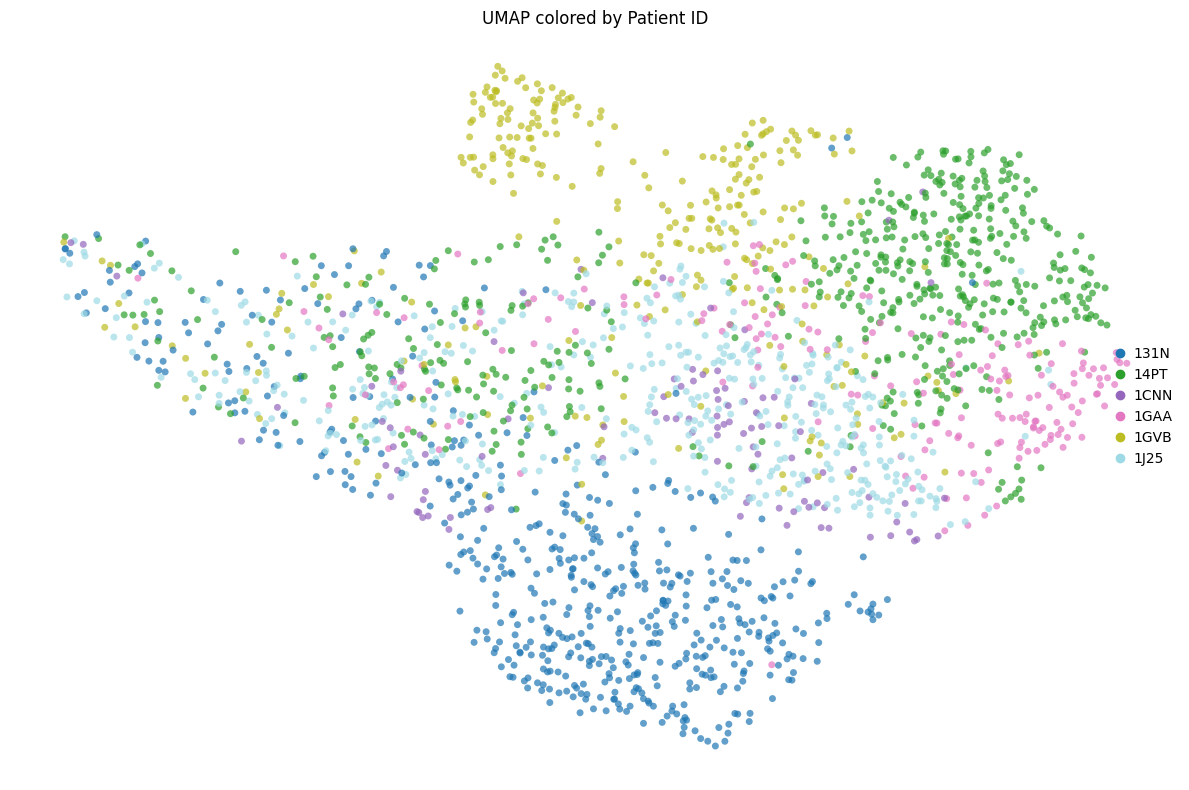

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
from matplotlib.patches import Patch

# Extract patient ID from organoid_id
def extract_patient_id(organoid_id):
    """Extract patient ID from organoid_id string by splitting on __"""
    parts = organoid_id.split('__')
    if len(parts) >= 3:
        return parts[2]  # Patient ID is the 3rd element
    else:
        return "unknown"

# Apply to the subsampled data
adata_subsampled.obs['patient_id'] = adata_subsampled.obs['organoid_id'].apply(extract_patient_id)
adata_subsampled.obs['patient_id'] = adata_subsampled.obs['patient_id'].astype('category')

# Compute UMAP if not already done
sc.pp.neighbors(adata_subsampled, use_rep='X')
sc.tl.umap(adata_subsampled)

# Create the plot with clean side legend
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# FIRST: Get the actual unique patient IDs present in the subsampled data
unique_patients_in_plot = adata_subsampled.obs['patient_id'].unique()

# Plot UMAP without legend on the left
sc.pl.umap(
    adata_subsampled,
    color='patient_id',
    legend_loc="right",  # No built-in legend
    palette='tab20',
    size=100,
    alpha=0.7,
    frameon=False,
    show=False,
    ax=ax,
    title='UMAP colored by Patient ID'
)

# SECOND: Use the same patient IDs that are actually in the plot
# Get the color mapping used by scanpy
color_map = dict(zip(unique_patients_in_plot, sc.pl.palettes.default_20[:len(unique_patients_in_plot)]))

# Calculate counts for each patient in the SUBSAMPLED data
patient_counts = adata_subsampled.obs['patient_id'].value_counts()

plt.tight_layout()
plt.show()

Original merged_adata shape: (2168, 512)
Using default tile size: 256x256
Attempting to overlay 108 tile images...


100%|██████████| 108/108 [02:08<00:00,  1.19s/it]


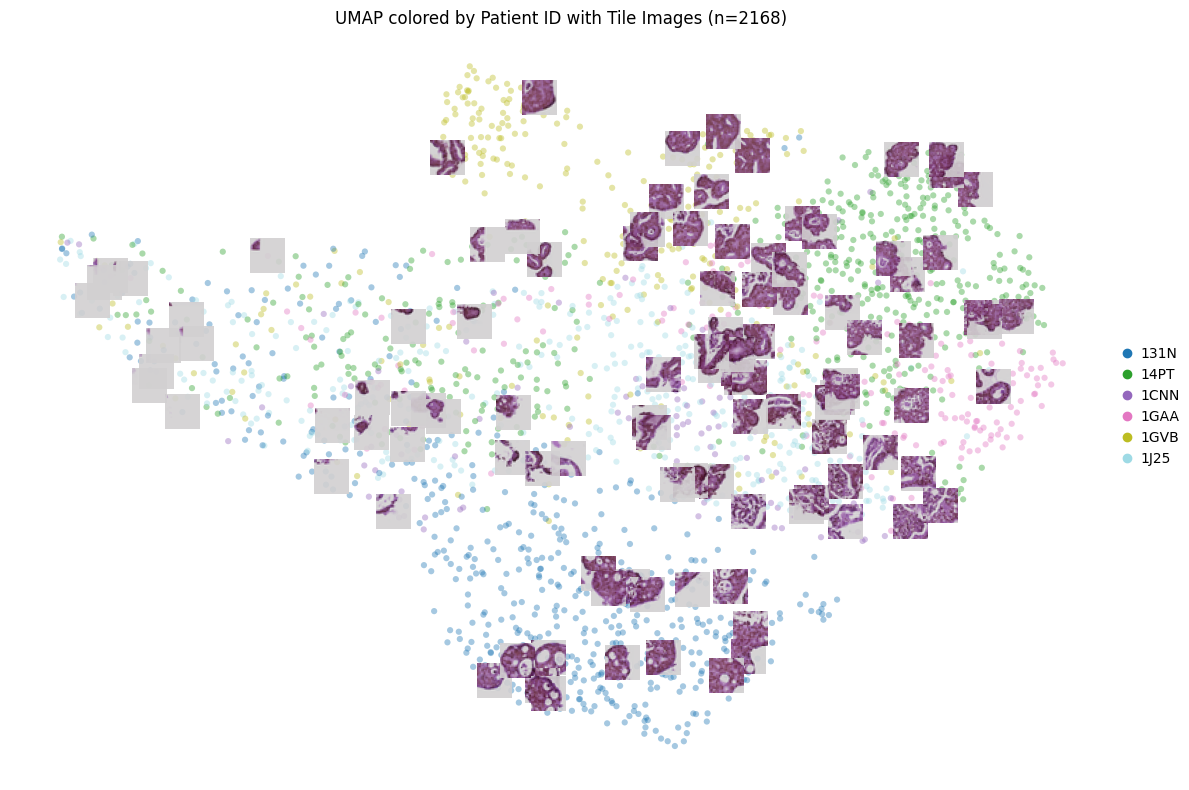

Successfully overlaid 108 tile images on UMAP
Total tiles attempted: 108


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import os
import random
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import lazyslide as zs
from wsidata import open_wsi
from tqdm import tqdm

def extract_patient_id(organoid_id):
    """Extract patient ID from organoid_id string by splitting on __"""
    parts = organoid_id.split('__')
    if len(parts) >= 3:
        return parts[2]  # Patient ID is the 3rd element
    else:
        return "unknown"

def extract_tile_image(organoid_id, tile_coords, target_size=(30, 30)):
    """Extract tile image from the organoid using lazyslide"""
    try:
        # Path to the organoid OME-TIFF
        organoid_path = os.path.join("/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoids_h&e/images", f"{organoid_id}.ome.tiff")
        
        if not os.path.exists(organoid_path):
            print(f"Organoid file not found: {organoid_path}")
            return None
        
        # Open the WSI
        wsi = open_wsi(organoid_path)
        
        # Extract the tile using the coordinates
        x, y, width, height = tile_coords
        tile_img = wsi.read_region(x, y, width, height)

        def replace_trailing_block(image, new_color=[210, 208, 209]):
            result = image.copy()
            for i in range(result.shape[0]):
                row = result[i]
                non_zero_mask = ~np.all(row == [0, 0, 0], axis=1)
                if np.any(non_zero_mask):
                    last_non_zero = np.where(non_zero_mask)[0][-1]
                    result[i, last_non_zero+1:] = new_color
                else:
                    result[i] = new_color
            return result

        tile_img = replace_trailing_block(tile_img, new_color=[210, 208, 209])
        
        # Convert to numpy array and resize
        tile_array = np.array(tile_img)
        pil_img = Image.fromarray(tile_array)
        pil_img = pil_img.resize(target_size, Image.LANCZOS)
        
        return np.array(pil_img)
            
    except Exception as e:
        print(f"Could not extract tile for {organoid_id}: {e}")
        return None

# SUBSAMPLE THE MERGED_ANNDATA
print(f"Original merged_adata shape: {merged_adata.shape}")

# Set random seed for reproducibility
np.random.seed(42)

# Apply patient ID extraction to subsampled data
adata_subsampled.obs['patient_id'] = adata_subsampled.obs['organoid_id'].apply(extract_patient_id)
adata_subsampled.obs['patient_id'] = adata_subsampled.obs['patient_id'].astype('category')

# Compute UMAP on subsampled data
sc.pp.neighbors(adata_subsampled, use_rep='X')
sc.tl.umap(adata_subsampled)

# Create single figure
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot UMAP with legend on the right
sc.pl.umap(
    adata_subsampled,
    color='patient_id',
    legend_loc="right margin",
    palette='tab20',
    size=80,
    alpha=0.4,
    frameon=False,
    show=False,
    ax=ax,
    title=f'UMAP colored by Patient ID with Tile Images (n={adata_subsampled.n_obs})'
)

# Get UMAP coordinates and organoid info
umap_coords = adata_subsampled.obsm['X_umap']
organoid_ids = adata_subsampled.obs['organoid_id']

# Get tile coordinates from the AnnData
tile_coords_x = adata_subsampled.obsm['spatial'][:, 0]
tile_coords_y = adata_subsampled.obsm['spatial'][:, 1]

# Get tile dimensions - handle different possible locations
if 'tile_spec' in adata_subsampled.uns:
    tile_widths = adata_subsampled.uns['tile_spec']['width']
    tile_heights = adata_subsampled.uns['tile_spec']['height']
elif 'tile_width' in adata_subsampled.obs.columns:
    tile_widths = adata_subsampled.obs['tile_width'].values
    tile_heights = adata_subsampled.obs['tile_height'].values
else:
    # Default tile size
    tile_widths = 1484
    tile_heights = 1484
    print("Using default tile size: 256x256")

# Sample 5% of points to overlay with tile images
n_samples = max(1, int(0.05 * len(umap_coords)))
sampled_indices = random.sample(range(len(umap_coords)), n_samples)

print(f"Attempting to overlay {n_samples} tile images...")

# Overlay tile images on sampled points
successful_overlays = 0
for idx in tqdm(sampled_indices):
    organoid_id_base = os.path.basename(organoid_ids.iloc[idx]).replace('_features', '')
    
    # Get tile coordinates for this point
    tile_coords = (
        int(tile_coords_x[idx]),
        int(tile_coords_y[idx]),
        int(tile_widths[idx] if hasattr(tile_widths, '__getitem__') else tile_widths),
        int(tile_heights[idx] if hasattr(tile_heights, '__getitem__') else tile_heights)
    )
    
    # Extract and overlay the tile image
    tile_img = extract_tile_image(organoid_id_base, tile_coords, target_size=(25, 25))
    
    if tile_img is not None:
        imagebox = OffsetImage(tile_img, zoom=1.0, alpha=0.9)
        ab = AnnotationBbox(imagebox, (umap_coords[idx, 0], umap_coords[idx, 1]),
                           frameon=False, pad=0.0, boxcoords="data")
        ax.add_artist(ab)
        successful_overlays += 1
    else:
        print(f"Failed to extract tile for {organoid_id_base}")

plt.tight_layout()
plt.show()

print(f"Successfully overlaid {successful_overlays} tile images on UMAP")
print(f"Total tiles attempted: {n_samples}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import os
import random
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
from tqdm import tqdm

# Extract patient ID from organoid_id
def extract_patient_id(organoid_id):
    """Extract patient ID from organoid_id string by splitting on __"""
    parts = organoid_id.split('__')
    if len(parts) >= 3:
        return parts[2]  # Patient ID is the 3rd element
    else:
        return "unknown"

def get_organoid_preview_path(organoid_id):
    """Convert organoid_id to preview image path"""
    base_name = os.path.basename(organoid_id)
    preview_path = os.path.join("/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoids_h&e/image_previews", f"{base_name}.png")
    return preview_path

def load_and_resize_image(image_path, target_size=(80, 80)):  # Increased size
    """Load and resize image for annotation"""
    try:
        img = plt.imread(image_path)
        # Handle different image formats
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)
        else:
            img = img.astype(np.uint8)
        
        # Convert to PIL and resize
        if len(img.shape) == 3 and img.shape[2] == 4:  # RGBA
            pil_img = Image.fromarray(img, 'RGBA')
        else:  # RGB or grayscale
            pil_img = Image.fromarray(img, 'RGB')
            
        pil_img = pil_img.resize(target_size, Image.LANCZOS)
        return np.array(pil_img)
    except Exception as e:
        print(f"Could not load image {image_path}: {e}")
        return None

# Apply to the subsampled data
adata_subsampled.obs['patient_id'] = adata_subsampled.obs['organoid_id'].apply(extract_patient_id)
adata_subsampled.obs['patient_id'] = adata_subsampled.obs['patient_id'].astype('category')

# Compute UMAP if not already done
sc.pp.neighbors(adata_subsampled, use_rep='X')
sc.tl.umap(adata_subsampled)

# Create single figure
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot UMAP with legend on the right - REDUCE ALPHA so images are visible
sc.pl.umap(
    adata_subsampled,
    color='patient_id',
    legend_loc="right margin",
    palette='tab20',
    size=80,  # Smaller points
    alpha=0.4,  # More transparent so images show through
    frameon=False,
    show=False,
    ax=ax,
    title='UMAP colored by Patient ID with Organoid Previews'
)

# Get UMAP coordinates
umap_coords = adata_subsampled.obsm['X_umap']
organoid_ids = adata_subsampled.obs['organoid_id']

# Sample 5% of points to overlay with images
n_samples = max(1, int(0.05 * len(umap_coords)))
sampled_indices = random.sample(range(len(umap_coords)), n_samples)

print(f"Attempting to overlay {n_samples} images...")

# Overlay images on sampled points
successful_overlays = 0
for idx in tqdm(sampled_indices):
    organoid_id = organoid_ids.iloc[idx]
    preview_path = get_organoid_preview_path(organoid_id)
    preview_path = preview_path.replace("_features", "")
    
    print(f"Looking for image: {preview_path}")
    
    if os.path.exists(preview_path):
        print(f"Found image for {organoid_id}")
        img = load_and_resize_image(preview_path, target_size=(30, 30))  # Larger size
        
        if img is not None:
            # Create image box with higher zoom and alpha
            imagebox = OffsetImage(img, zoom=1.0, alpha=0.9)  # More opaque
            ab = AnnotationBbox(imagebox, (umap_coords[idx, 0], umap_coords[idx, 1]),
                               frameon=True, pad=0.0, boxcoords="data")
            ax.add_artist(ab)
            successful_overlays += 1
            print(f"Successfully added image for {organoid_id}")
        else:
            print(f"Failed to load image for {organoid_id}")
    else:
        print(f"Image not found: {preview_path}")

plt.tight_layout()
plt.show()

print(f"Successfully overlaid {successful_overlays} organoid preview images on UMAP")
print(f"Total images attempted: {n_samples}")

# UMAPs

## By Patient

## By Organoid